In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
data = pd.read_csv('El_components.csv', delimiter=',')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   avg_component_price         180 non-null    int64
 1   promo_days_count            180 non-null    int64
 2   is_tech_expo_month          180 non-null    int64
 3   online_orders_share         180 non-null    int64
 4   supplier_reliability_index  180 non-null    int64
 5   monthly_components_sales    180 non-null    int64
dtypes: int64(6)
memory usage: 8.6 KB


In [4]:
features = ['avg_component_price', 'promo_days_count',
            'is_tech_expo_month', 'online_orders_share',
            'supplier_reliability_index']

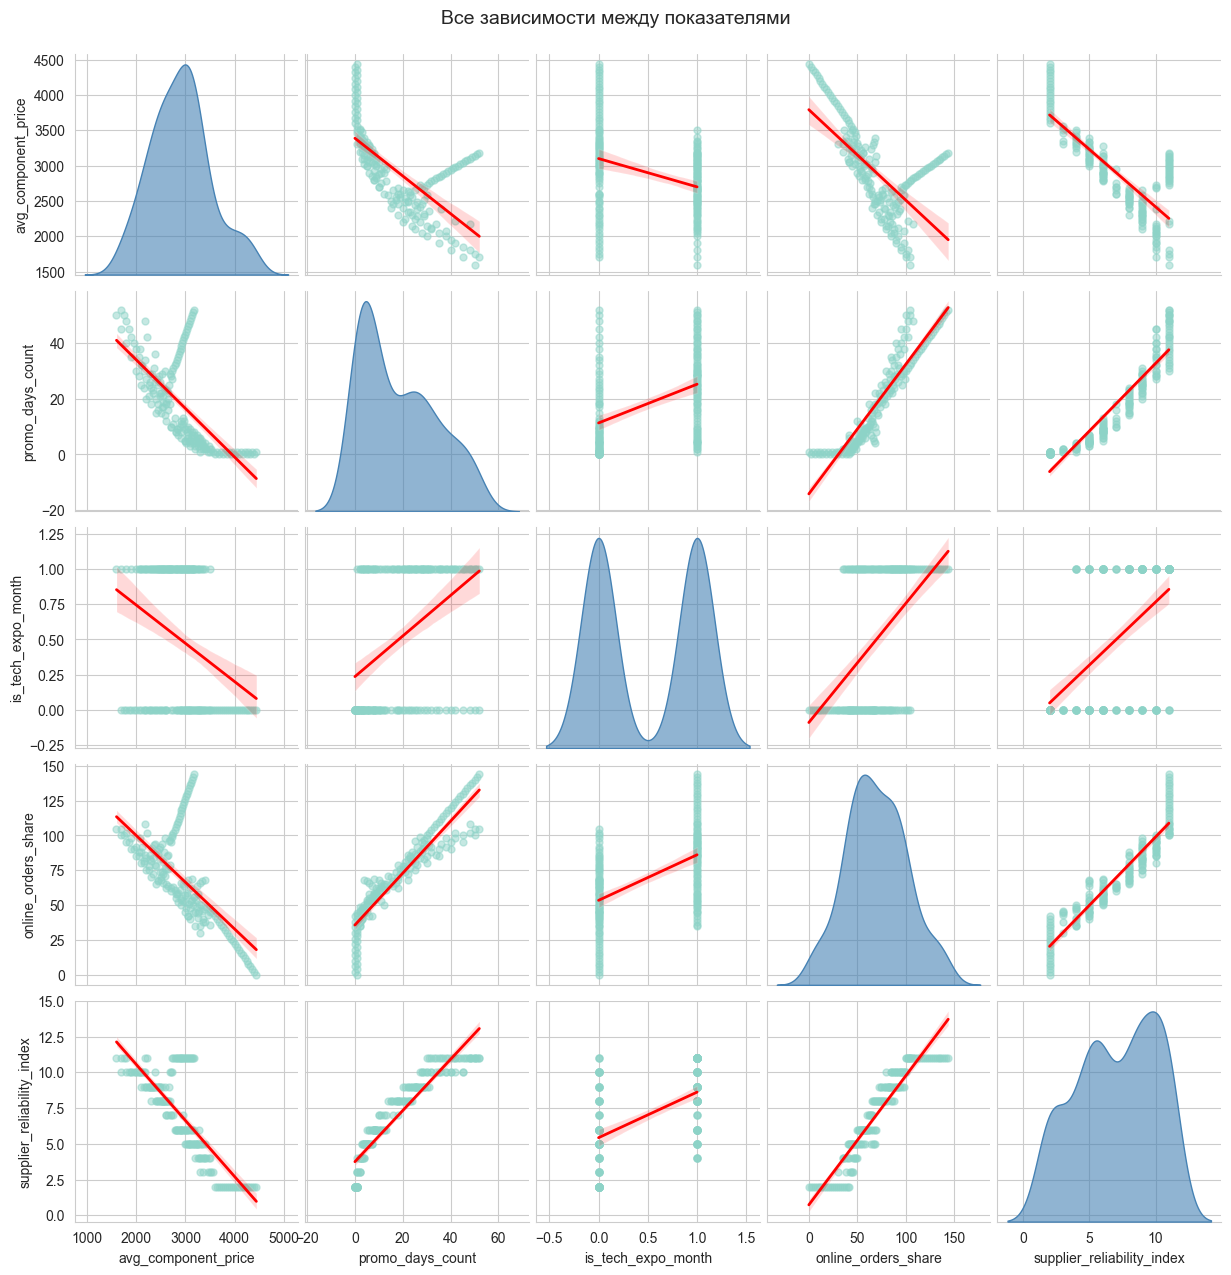

In [14]:
# Исправленный вариант с учетом новых параметров seaborn
g = sns.pairplot(data[features],
                 kind='reg',
                 diag_kind='kde',
                 plot_kws={'line_kws': {'color': 'red', 'linewidth': 2},
                          'scatter_kws': {'alpha': 0.5, 's': 25}},
                 diag_kws={'fill': True, 'color': 'steelblue', 'alpha': 0.6})  # shade → fill
g.fig.suptitle('Все зависимости между показателями', y=1.02, fontsize=14)
plt.show()

In [16]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Нормализация данных (для нейросетей)
scaler_X = {}
scaler_y = {}

# Разделение на обучающую и тестовую выборки
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

models_dict = {}
results = []  # Сохраняем результаты в список

for target in features:
    for feature in features:
        if target == feature:
            continue  # пропускаем предсказание параметра самого себя

        model_key = f"{feature}+{target}"
        X_train = train_data[[feature]].values
        Y_train = train_data[[target]].values

        # Создание и обучение модели
        model = LinearRegression()
        model.fit(X_train, Y_train)

        # Сохранение модели
        models_dict[model_key] = model

        # Оценка на тестовых данных (опционально)
        X_test = test_data[[feature]].values
        y_test = test_data[[target]].values
        y_pred = model.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results.append({
            'model': model_key,
            'mse': mse,
            'r2': r2
        })

results_df = pd.DataFrame(results)
results_df.to_csv('models_results.csv', index=False)
print("Результаты сохранены в 'models_results.csv'")

Результаты сохранены в 'models_results.csv'


In [ ]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers, models
from tensorflow import keras


def create_meta_features(data, models, features):
    """Создаёт мета-признаки: все 20 предсказаний для каждой строки"""
    meta_features = []

    for idx in range(len(data)):
        row_preds = []
        for target in features:
            for feature in features:
                if target == feature:
                    continue
                model_key = f"{feature}→{target}"
                X_input = data[[feature]].iloc[idx].values.reshape(-1, 1)
                pred = models[model_key].predict(X_input)[0][0]
                row_preds.append(pred)
        meta_features.append(row_preds)

    return np.array(meta_features)

# Создаём мета-признаки для train и test
print("Создание мета-признаков для обучающей выборки...")
X_meta_train = create_meta_features(train_data, models_dict, features)

print("Создание мета-признаков для тестовой выборки...")
X_meta_test = create_meta_features(test_data, models_dict, features)

# Целевые значения (реальные параметры)
y_train = train_data[features].values
y_test = test_data[features].values

print(f"Форма мета-признаков: {X_meta_train.shape}")  # должно быть (n_samples, 20)
print(f"Форма целевых значений: {y_train.shape}")      # должно быть (n_samples, 5)

# ============================================
# ШАГ 3: Нормализация данных
# ============================================
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_meta_train_scaled = scaler_X.fit_transform(X_meta_train)
X_meta_test_scaled = scaler_X.transform(X_meta_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# ============================================
# ШАГ 4: Создаём нейросеть, которая объединяет все предсказания
# ============================================
def create_ensemble_nn(input_dim=20, output_dim=5):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),

        # Скрытые слои
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),

        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),

        layers.Dense(16, activation='relu'),

        # Выходной слой (5 параметров)
        layers.Dense(output_dim, activation='linear')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    return model

# Создаём модель
ensemble_model = create_ensemble_nn(input_dim=20, output_dim=5)
ensemble_model.summary()

# ============================================
# ШАГ 5: Обучение объединённой модели
# ============================================
history = ensemble_model.fit(
    X_meta_train_scaled, y_train_scaled,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1
)

# ============================================
# ШАГ 6: Оценка модели
# ============================================
# Предсказания на тестовой выборке
y_pred_scaled = ensemble_model.predict(X_meta_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# Сравнение с реальными значениями
from sklearn.metrics import mean_squared_error, r2_score

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ОБЪЕДИНЁННОЙ МОДЕЛИ")
print("="*60)

for i, feature in enumerate(features):
    mse = mean_squared_error(y_test[:, i], y_pred[:, i])
    r2 = r2_score(y_test[:, i], y_pred[:, i])
    print(f"{feature:30} | MSE: {mse:10.2f} | R²: {r2:.4f}")

# ============================================
# Сохранение модели
# ============================================
ensemble_model.save('ensemble_neural_network.h5')
print("\n✅ Модель сохранена как 'ensemble_neural_network.h5'")